In [ ]:
import json
import re
import time
from pathlib import Path

import altair as alt
import cobra
import marimo as mo
import numpy as np
import pandas as pd
import polars as pl
import requests

# Two-tier eval for VAE-designed genomes

Lightweight replacement for the vEcoli whole-cell-model eval: KEGG
functional coverage plus iML1515 FBA. Both are deterministic, cached, and
runnable in minutes.

- **Tier 1 — KEGG module coverage.** ≈110 small functional modules.
- **Tier 2 — iML1515 FBA.** Knock out absent metabolic genes and solve
  for growth on glucose minimal medium.

Sources compared throughout:
- **real** — 100 strains sampled from the pangenome matrix
- **random** — frequency-weighted core+accessory baseline
- **[v3](https://huggingface.co/UCL-CSSB/genome-minimizer-2/tree/v3)** — HF UCL-CSSB `v3/final.pt` (epoch 2363, no essential-gene loss; latent_dim=32, hidden_dim=512), 100 samples, seed 42
- **[v4_opt](https://huggingface.co/McClain/genome-minimizer-2/tree/v4_opt)** — HF McClain `v4_opt/final.pt` (epoch 500, = v3 + essential-gene preservation loss, hyperparameter-tuned: lr 7.5e-4, essential_weight 0.5), 100 samples, seed 42

Both v3 and v4_opt are sampled with essential gene repair, meaning the lit essential genes are added back in at inference time as a post-processing step. "Random" means we took the core genome then appended accessory genes to it at random until we hit the expected number of total genes.

The `real` cohort is a reference distribution sampled from the same
pangenome used for training, not an independent holdout. That is fine for
asking whether generated genomes look biologically plausible relative to
known *E. coli* gene-content variation; it should not be presented as a
generalization test.

In [ ]:
PROJECT_ROOT = Path(__file__).resolve().parents[1]
DATA_DIR = PROJECT_ROOT / "data"
KEGG_CACHE = DATA_DIR / "kegg"
FBA_DIR = DATA_DIR / "fba"
EVAL_DATA = PROJECT_ROOT / "evaluation" / "data"

KEGG_CACHE.mkdir(parents=True, exist_ok=True)

## 1. Pull KEGG module definitions

KEGG **modules** (M-numbers) are small functional units — e.g. M00001 =
"Glycolysis (Embden-Meyerhof pathway), glucose => pyruvate". They cover
525 *E. coli* genes across 112 modules with median size 5 genes.

Three KEGG REST hits:

1. `list/module` → all 570 KEGG modules with names
2. `list/eco` → every *E. coli* gene KEGG knows about, with its primary
   gene symbol (used for the symbol → b-number crosswalk in §2)
3. `link/module/eco` → one bulk file mapping every *E. coli* gene to
   every module it appears in

All responses are cached as flat TSVs under `data/kegg/`. Re-running the
notebook hits zero network. Cache is committed so the analysis is
reproducible without internet access.

In [ ]:
KEGG_BASE = "https://rest.kegg.jp"

def fetch_kegg(endpoint: str, cache_path):
    if cache_path.exists():
        return cache_path.read_text()
    url = f"{KEGG_BASE}/{endpoint}"
    r = requests.get(url, timeout=30)
    r.raise_for_status()
    text = r.text
    cache_path.parent.mkdir(parents=True, exist_ok=True)
    cache_path.write_text(text)
    time.sleep(0.34)
    return text

modules_text = fetch_kegg("list/module", KEGG_CACHE / "modules.tsv")
eco_genes_text = fetch_kegg("list/eco", KEGG_CACHE / "eco_genes.tsv")
eco_module_links_text = fetch_kegg(
    "link/module/eco", KEGG_CACHE / "eco_module_links.tsv"
)

In [ ]:
module_genes = {}
for _line in eco_module_links_text.strip().splitlines():
    _parts = _line.split("\t")
    if len(_parts) < 2:
        continue
    _gene = _parts[0].removeprefix("eco:")
    _mid = _parts[1].removeprefix("md:eco_").removeprefix("md:")
    module_genes.setdefault(_mid, set()).add(_gene)

_sizes = sorted(len(v) for v in module_genes.values())
print(
    f"E. coli modules: {len(module_genes)} | "
    f"unique genes across modules: {len({g for s in module_genes.values() for g in s})} | "
    f"median module size: {_sizes[len(_sizes) // 2]} genes | "
    f"min={_sizes[0]} max={_sizes[-1]}"
)

E. coli modules: 112 | unique genes across modules: 525 | median module size: 5 genes | min=1 max=23


E. coli modules with names resolved: 112


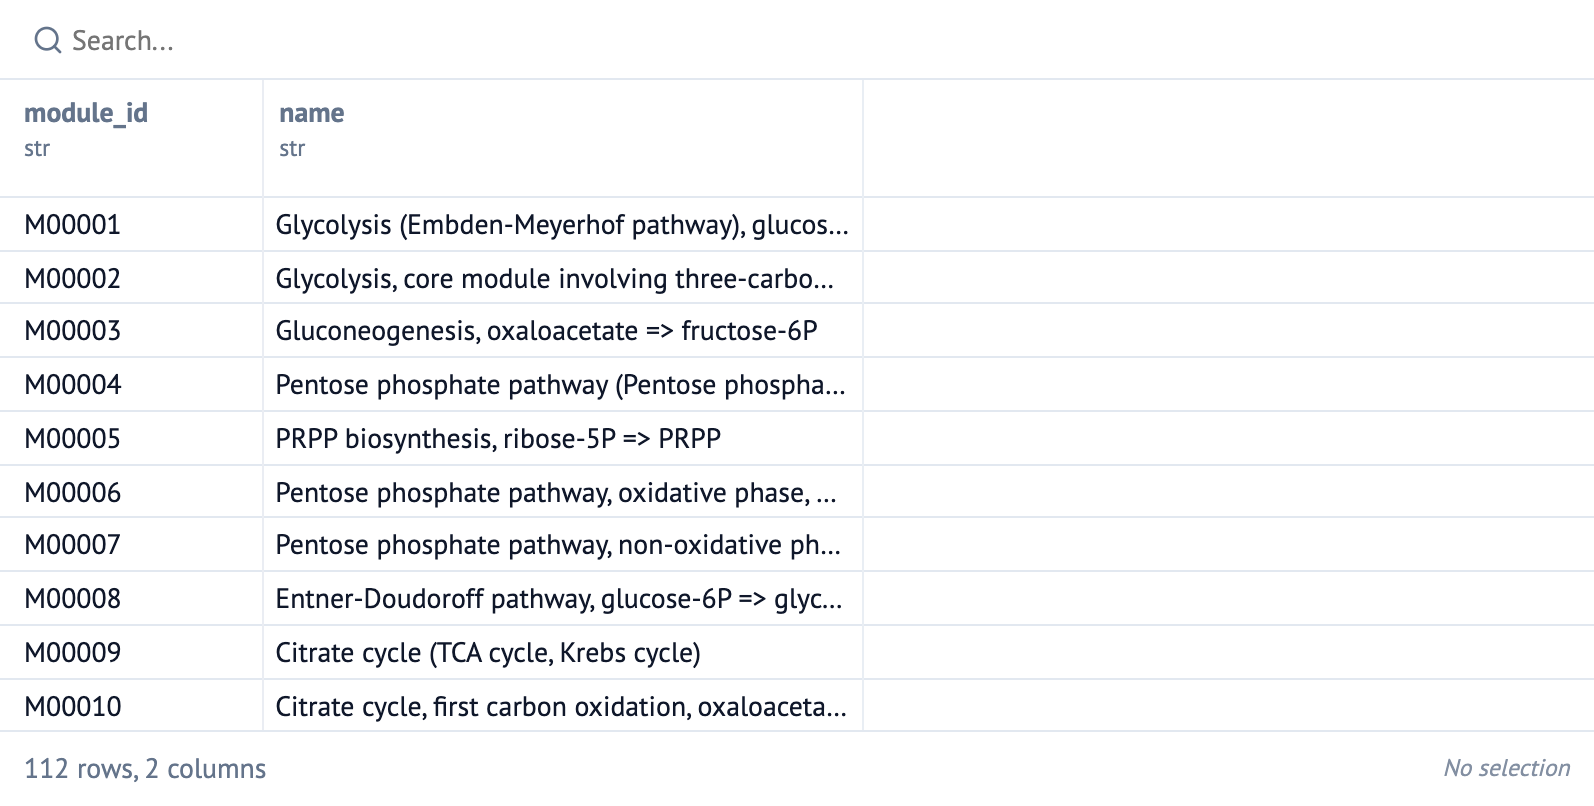

In [ ]:
_eco_module_ids = set(module_genes.keys())
_rows = []
for _line in modules_text.strip().splitlines():
    _parts = _line.split("\t")
    if len(_parts) < 2:
        continue
    _mid = _parts[0].strip()
    if _mid in _eco_module_ids:
        _rows.append({"module_id": _mid, "name": _parts[1]})

modules_df = pl.DataFrame(_rows)
print(f"E. coli modules with names resolved: {modules_df.height}")
modules_df

## 2. Crosswalk pangenome gene names → KEGG b-numbers

The pangenome (`F4_complete_presence_absence.csv`) labels genes with
Panaroo-style symbols (e.g. `accA`, `aaeA_1`, `aaeA_2` for paralogs) plus
~45k `group_XXXX` clusters for accessory genes that didn't get a name.
KEGG indexes everything by *b-number* (e.g. `b0185` = `accA`).

For each named pangenome gene we (1) try an exact symbol match against
KEGG, (2) try after stripping the Panaroo paralog suffix `_N`. The
`group_XXXX` clusters are skipped — they're accessory and almost never
in KEGG metabolic modules anyway.

The unmatched named genes are dominated by conjugation / plasmid genes
(`virB*`, `traD*`, `mbeA`, …) which is expected: KEGG metabolic modules
don't include horizontal-transfer machinery.

In [ ]:
symbol_to_bnum = {}
for _line in eco_genes_text.strip().splitlines():
    _parts = _line.split("\t")
    if len(_parts) < 4:
        continue
    _bnum = _parts[0].removeprefix("eco:")
    _info = _parts[3]
    _symbol_part = _info.split(";")[0].strip()
    for _sym in _symbol_part.split(","):
        _key = _sym.strip().lower()
        if _key:
            symbol_to_bnum[_key] = _bnum

print(f"KEGG symbol→b-number entries: {len(symbol_to_bnum)}")

KEGG symbol→b-number entries: 4638


In [ ]:
def normalize_gene(name: str) -> str:
    return re.sub(r"_\d+$", "", name).lower()

pangenome_index = pd.read_csv(
    DATA_DIR / "F4_complete_presence_absence.csv",
    index_col=0,
    usecols=[0],
).index
pangenome_genes = [g for g in pangenome_index if g != "Lineage"]

n_named = sum(1 for g in pangenome_genes if not g.startswith("group_"))
n_groups = sum(1 for g in pangenome_genes if g.startswith("group_"))
print(
    f"Pangenome: {len(pangenome_genes)} entries "
    f"({n_named} named, {n_groups} group_XXXX clusters)"
)

Pangenome: 55039 entries (9506 named, 45533 group_XXXX clusters)


In [ ]:
pangenome_to_bnum = {}
unmatched_named = []
for _g in pangenome_genes:
    if _g.startswith("group_"):
        continue
    _key = _g.lower()
    if _key in symbol_to_bnum:
        pangenome_to_bnum[_g] = symbol_to_bnum[_key]
        continue
    _norm = normalize_gene(_g)
    if _norm in symbol_to_bnum:
        pangenome_to_bnum[_g] = symbol_to_bnum[_norm]
        continue
    unmatched_named.append(_g)

n_named_total = sum(1 for g in pangenome_genes if not g.startswith("group_"))
print(
    f"Crosswalk: {len(pangenome_to_bnum)} / {n_named_total} named pangenome genes "
    f"matched to KEGG ({len(pangenome_to_bnum) / n_named_total * 100:.1f}%)"
)
print(f"Unique b-numbers covered: {len(set(pangenome_to_bnum.values()))}")
print(f"\nFirst 20 unmatched named genes: {unmatched_named[:20]}")
assert 2000 <= len(pangenome_to_bnum) <= 6000, (
    f"Match count {len(pangenome_to_bnum)} outside sanity range [2000, 6000] — "
    "inspect crosswalk before proceeding."
)

Crosswalk: 5338 / 9506 named pangenome genes matched to KEGG (56.2%)
Unique b-numbers covered: 2944

First 20 unmatched named genes: ['virB1', 'flmC_1', 'colE7', 'sugE_1', 'virB4_2', 'virB5', 'virB8', 'traD_2', 'mbeA', 'imm_1', 'traA_2', 'ymoA', 'ifcA', 'virB9_2', 'parM_2', 'soj', 'higB2', 'virB6', 'virB9', 'traI_2']


## 3. Load all genome samples

Provenance check:
- `v3` reproduces UCL-CSSB `genome-minimizer-2` branch `v3`, `final.pt` (epoch 2363), sampled with seed 42.
- `v4_opt` reproduces McClain `genome-minimizer-2` branch `v4_opt`, `final.pt` (epoch 500), sampled with seed 42.

In [ ]:
def _load_real_strains(n_strains: int = 100, seed: int = 42):
    path = DATA_DIR / "F4_complete_presence_absence.csv"
    header = pd.read_csv(path, nrows=0).columns.tolist()
    strain_cols = [c for c in header[1:]]
    rng = np.random.default_rng(seed)
    chosen = rng.choice(len(strain_cols), size=n_strains, replace=False)
    chosen_names = [strain_cols[i] for i in sorted(chosen)]
    df = pd.read_csv(path, index_col=0, usecols=[header[0], *chosen_names])
    df = df.drop(index="Lineage", errors="ignore")
    out = []
    for col in df.columns:
        present = df.index[df[col].astype(int).values == 1].tolist()
        out.append((col, present))
    return out

real_strains = _load_real_strains(n_strains=100, seed=42)

def _load(p):
    return list(np.load(p, allow_pickle=True))

sample_sources = {
    "real": [(name, genes) for name, genes in real_strains],
    "random": [
        (f"random_{i:03d}", list(g))
        for i, g in enumerate(
            _load(EVAL_DATA / "random" / "random_gene_lists_with_essentials.npy")
        )
    ],
    "v3": [
        (f"v3_{i:03d}", list(g))
        for i, g in enumerate(
            _load(EVAL_DATA / "v3" / "v3_gene_lists_with_essentials.npy")
        )
    ],
    "v4_opt": [
        (f"v4_opt_{i:03d}", list(g))
        for i, g in enumerate(
            _load(EVAL_DATA / "v4_opt" / "v4_opt_gene_lists_with_essentials.npy")
        )
    ],
}
for _src, _items in sample_sources.items():
    _sizes = [len(genes) for _, genes in _items]
    print(
        f"{_src:>8s}: n={len(_items):3d}  genes/genome mean={int(np.mean(_sizes))} "
        f"min={min(_sizes)} max={max(_sizes)}"
    )

    real: n=100  genes/genome mean=4738 min=4192 max=5288
  random: n=100  genes/genome mean=3267 min=3266 max=3268
      v3: n=100  genes/genome mean=3217 min=2709 max=4072
  v4_opt: n=100  genes/genome mean=4565 min=4131 max=4977


### Genome-size distribution

First sanity check: generated genomes should land in a plausible gene-count
range before we interpret functional coverage. The random baseline is flat
because it was generated with a fixed `--target-gene-count`.

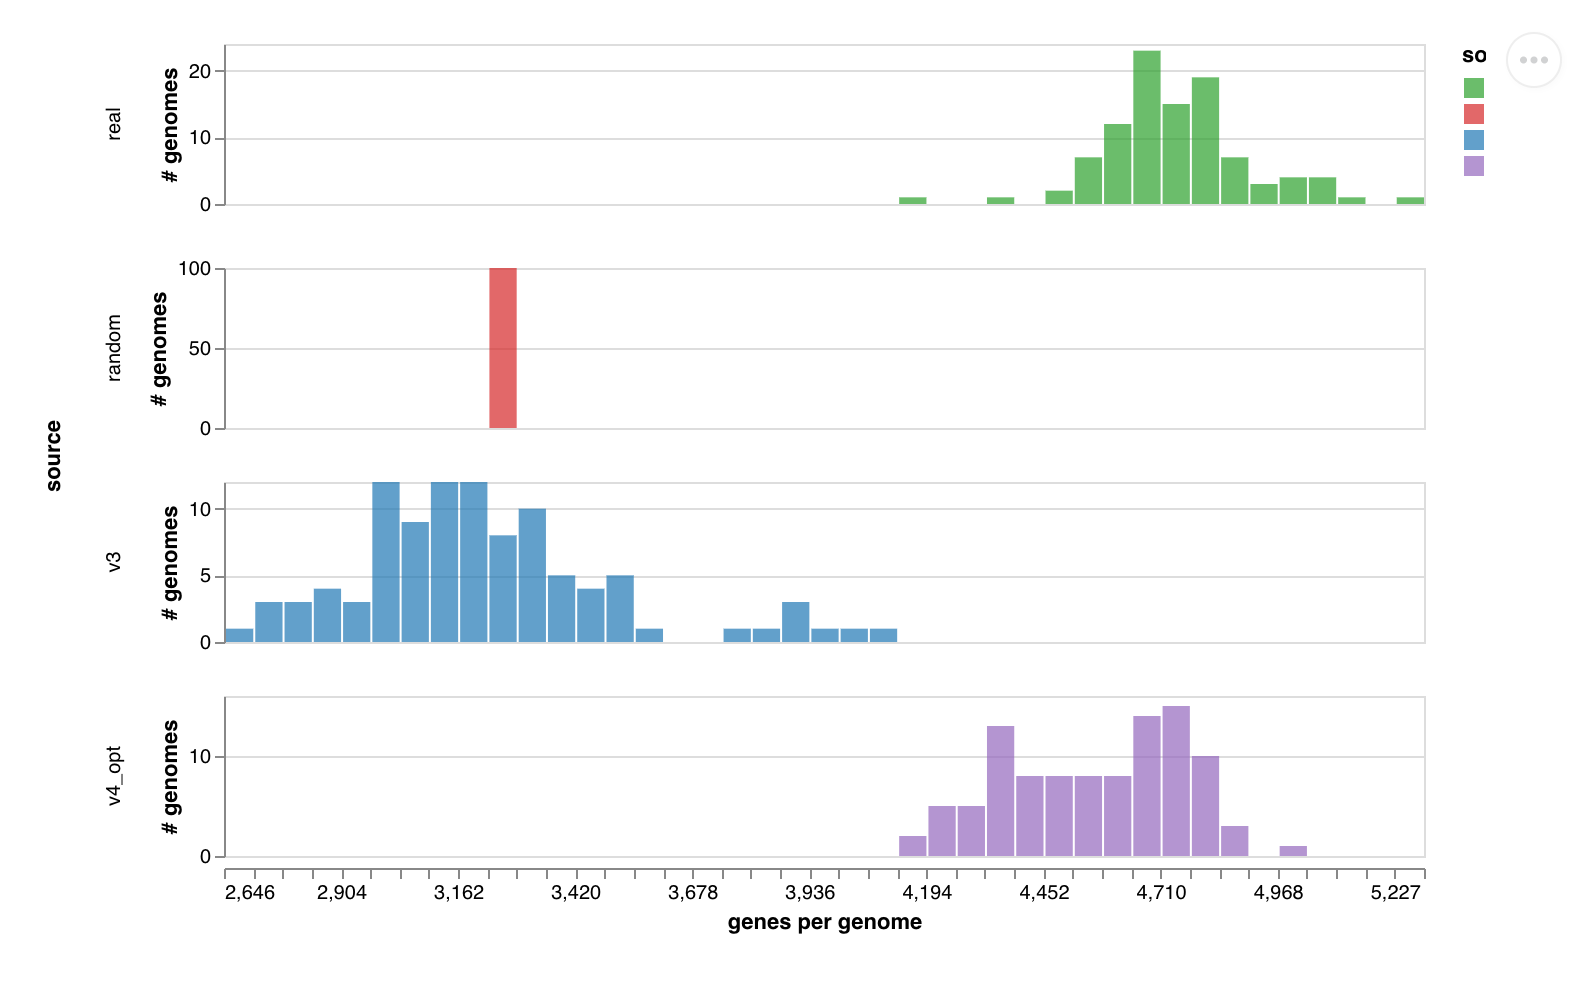

In [ ]:
_size_rows = [
    {"source": _src, "genome_id": _gid, "n_genes": len(_genes)}
    for _src, _items in sample_sources.items()
    for _gid, _genes in _items
]
sizes_df = pl.DataFrame(_size_rows)

_SRC_COLORS = {
    "real": "#2ca02c",
    "random": "#d62728",
    "v3": "#1f77b4",
    "v4_opt": "#9467bd",
}
_SRC_ORDER = ["real", "random", "v3", "v4_opt"]

_all_n = sizes_df["n_genes"].to_numpy()
_bin_edges = np.linspace(_all_n.min() - 1, _all_n.max() + 1, 41)

_hist = (
    alt.Chart(sizes_df.to_pandas())
    .mark_bar(opacity=0.7)
    .encode(
        x=alt.X(
            "n_genes:Q",
            bin=alt.Bin(extent=[float(_bin_edges[0]), float(_bin_edges[-1])], step=float(_bin_edges[1] - _bin_edges[0])),
            title="genes per genome",
        ),
        y=alt.Y("count():Q", title="# genomes"),
        color=alt.Color(
            "source:N",
            scale=alt.Scale(domain=_SRC_ORDER, range=[_SRC_COLORS[s] for s in _SRC_ORDER]),
        ),
        row=alt.Row("source:N", sort=_SRC_ORDER),
    )
    .properties(width=600, height=80)
    .resolve_scale(y="independent")
)
_hist

## 4. Score every genome against every module

For each genome we map its gene names to KEGG b-numbers, then for each
of the ~110 *E. coli* modules compute

$$
\text{completeness}_{g, m} = \frac{|G_g \cap M_m|}{|M_m|}
$$

where $G_g$ is the set of b-numbers in genome $g$ and $M_m$ is the set
of b-numbers KEGG assigns to module $m$. Result lives in `long_df` —
one row per (genome, module).

`summary_df` rolls up to one row per genome with two thresholds:
**# modules ≥ 80% complete** (lenient — allows one missing gene in
a 5-gene module) and **# modules = 100% complete (≥ 99% threshold)**
(strict — every gene present). Modules are small enough that 99% is
effectively the "fully reconstructed" criterion.

long_df: (44800, 4)


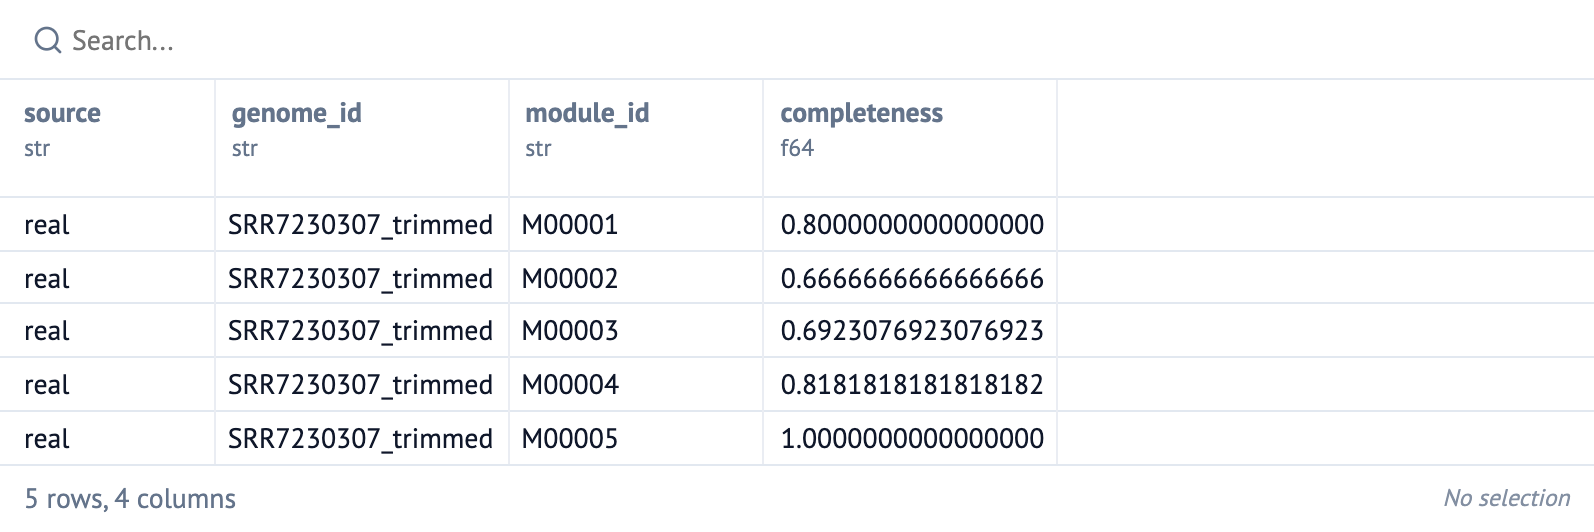

In [ ]:
def score_genome(gene_names):
    bnums = set()
    for g in gene_names:
        b = pangenome_to_bnum.get(g)
        if b is not None:
            bnums.add(b)
    return {
        pid: len(bnums & pgenes) / len(pgenes) if pgenes else 0.0
        for pid, pgenes in module_genes.items()
    }

rows = []
for _src, _items in sample_sources.items():
    for _gid, _genes in _items:
        _scores = score_genome(_genes)
        for _pid, _frac in _scores.items():
            rows.append(
                {
                    "source": _src,
                    "genome_id": _gid,
                    "module_id": _pid,
                    "completeness": _frac,
                }
            )

long_df = pl.DataFrame(rows)
print(f"long_df: {long_df.shape}")
long_df.head()

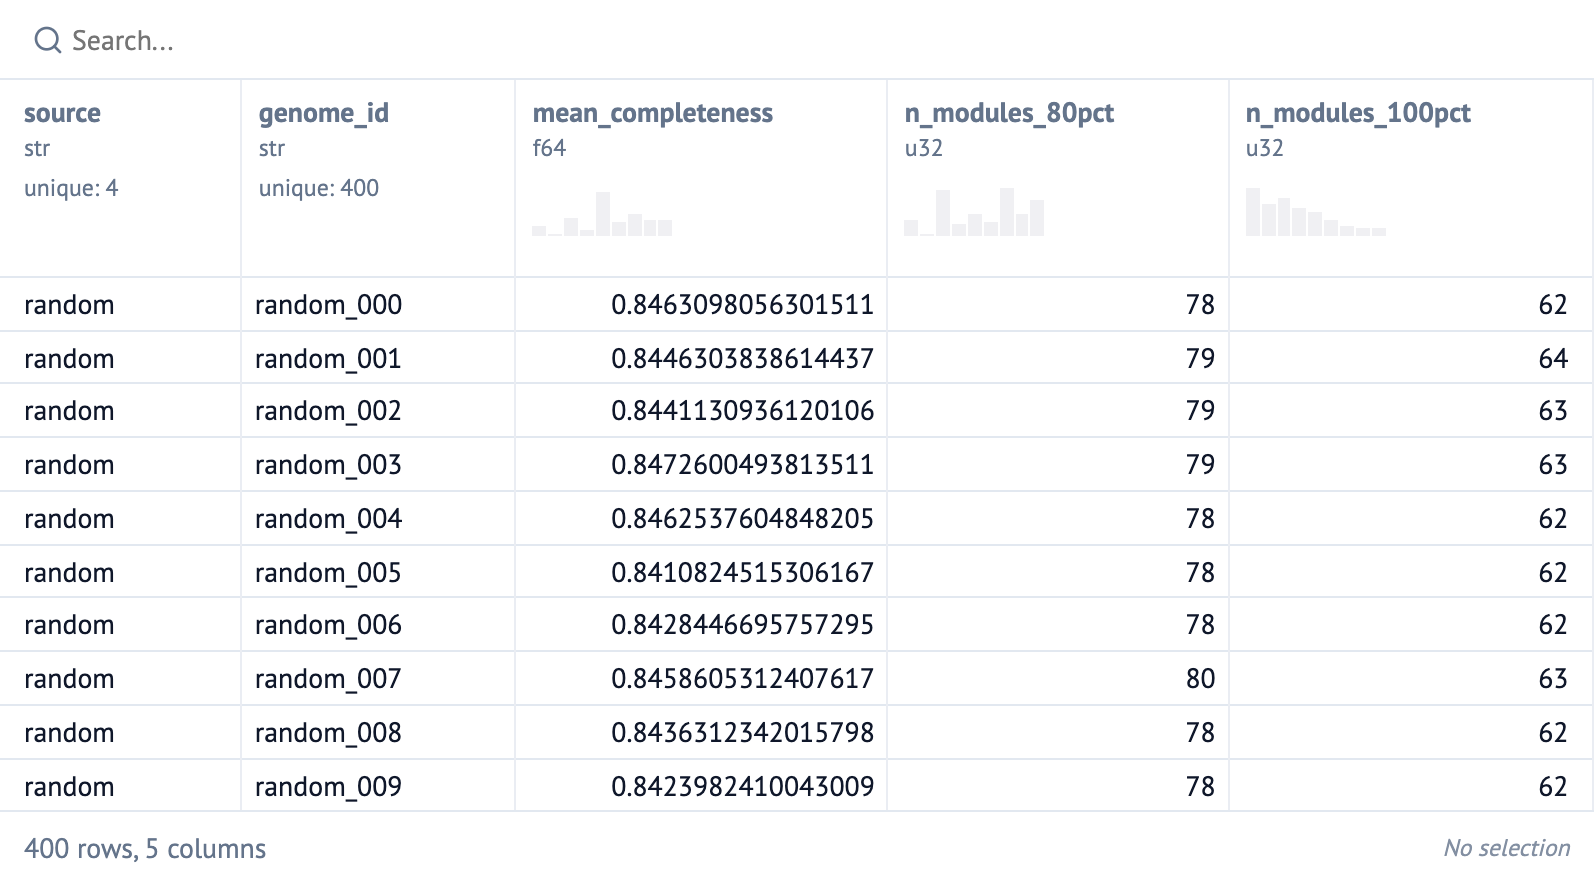

In [ ]:
summary_df = (
    long_df.group_by(["source", "genome_id"])
    .agg(
        [
            pl.col("completeness").mean().alias("mean_completeness"),
            (pl.col("completeness") >= 0.8).sum().alias("n_modules_80pct"),
            (pl.col("completeness") >= 0.99).sum().alias("n_modules_100pct"),
        ]
    )
    .sort(["source", "genome_id"])
)
summary_df

## 5. Distribution: modules above the threshold

The default 0.99 threshold is strict: for median 5-gene KEGG modules it is
effectively "all genes present." The random baseline is strong because it
keeps the full >95%-prevalence core genome and frequency-weights accessory
genes; it is not a naive uniform-random baseline.

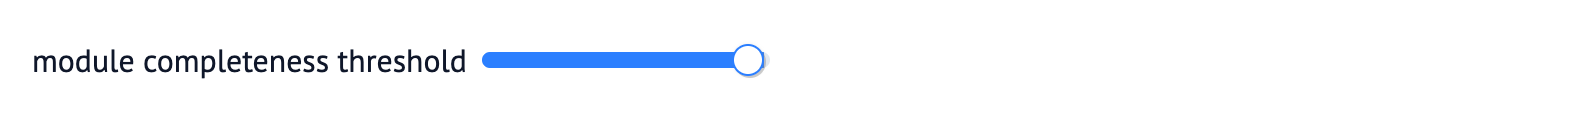

In [ ]:
threshold = mo.ui.slider(
    0.5, 1.0, value=0.99, step=0.01, label="module completeness threshold"
)
threshold

min(real n_modules) at threshold=0.87: 64


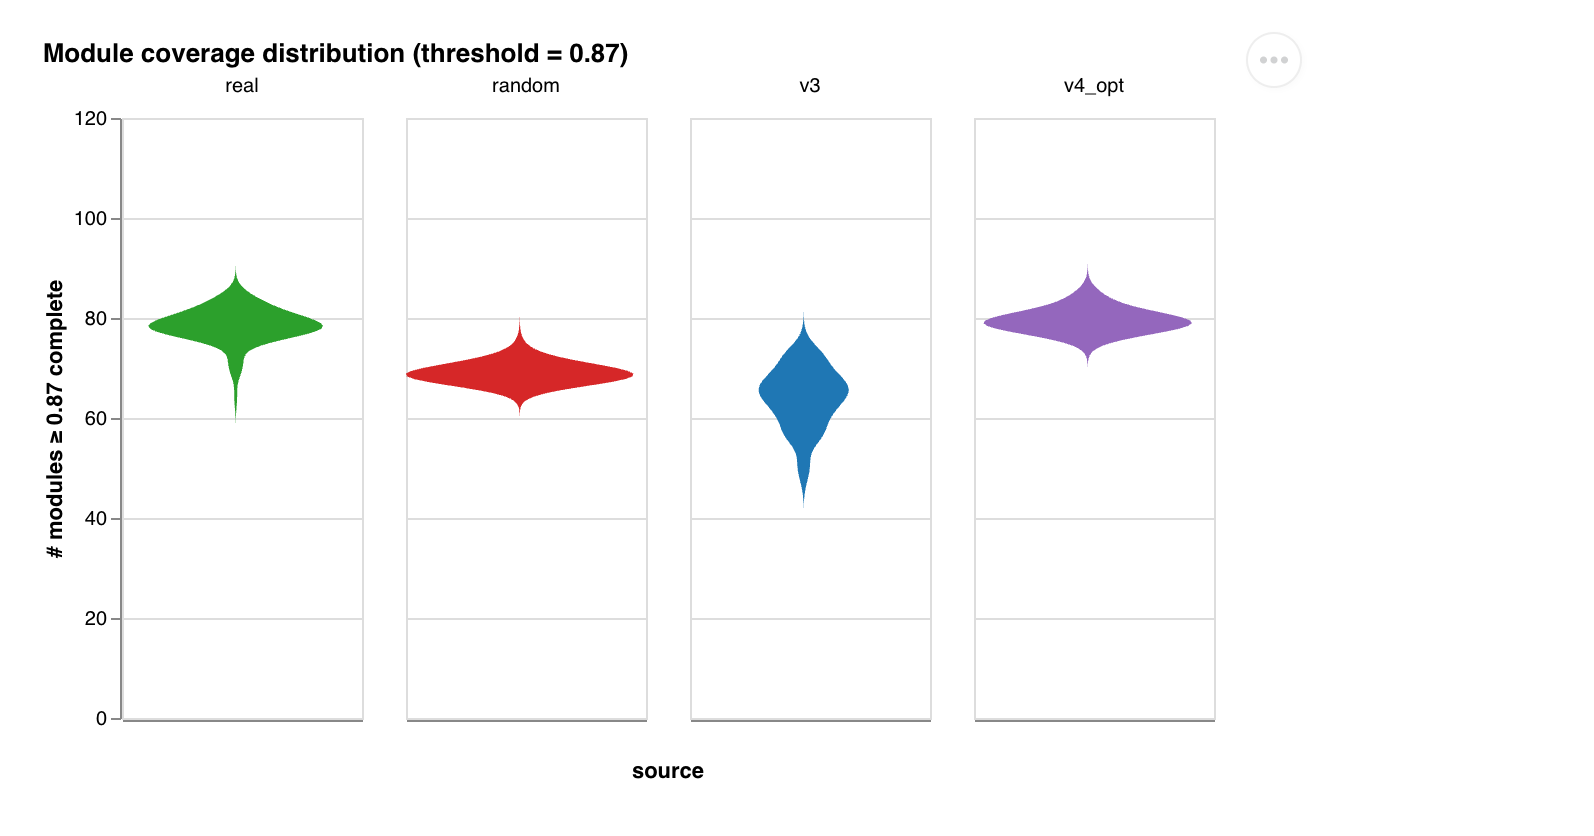

In [ ]:
_t = threshold.value
per_genome = (
    long_df.group_by(["source", "genome_id"])
    .agg((pl.col("completeness") >= _t).sum().alias("n_modules"))
    .sort(["source", "n_modules"])
)

_real_min = per_genome.filter(pl.col("source") == "real")["n_modules"].min()

_SOURCE_ORDER = ["real", "random", "v3", "v4_opt"]
_SOURCE_COLORS = {
    "real": "#2ca02c",
    "random": "#d62728",
    "v3": "#1f77b4",
    "v4_opt": "#9467bd",
}

_violin = (
    alt.Chart(per_genome.to_pandas())
    .transform_density(
        "n_modules",
        as_=["n_modules", "density"],
        groupby=["source"],
        extent=[0, 112],
        steps=200,
        bandwidth=2.0,
        counts=True,
    )
    .mark_area(orient="horizontal")
    .encode(
        y=alt.Y("n_modules:Q", title=f"# modules ≥ {_t:.2f} complete"),
        x=alt.X(
            "density:Q",
            stack="center",
            impute=None,
            title=None,
            axis=alt.Axis(labels=False, ticks=False, grid=False),
        ),
        color=alt.Color(
            "source:N",
            scale=alt.Scale(
                domain=list(_SOURCE_COLORS.keys()),
                range=list(_SOURCE_COLORS.values()),
            ),
            legend=None,
        ),
        column=alt.Column(
            "source:N", sort=_SOURCE_ORDER, header=alt.Header(titleOrient="bottom")
        ),
    )
    .properties(
        width=120,
        height=300,
        title=f"Module coverage distribution (threshold = {_t:.2f})",
    )
)

print(f"min(real n_modules) at threshold={_t:.2f}: {_real_min}")
_violin

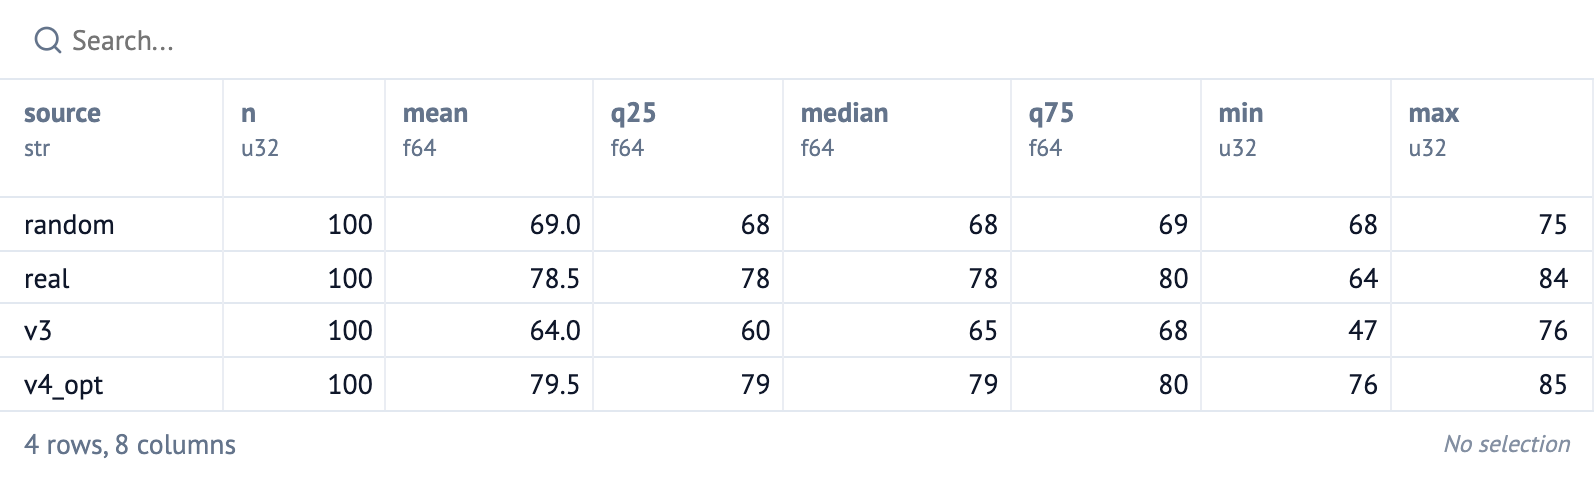

In [ ]:
descriptive = (
    per_genome.group_by("source")
    .agg(
        [
            pl.len().alias("n"),
            pl.col("n_modules").mean().round(1).alias("mean"),
            pl.col("n_modules").quantile(0.25).alias("q25"),
            pl.col("n_modules").median().alias("median"),
            pl.col("n_modules").quantile(0.75).alias("q75"),
            pl.col("n_modules").min().alias("min"),
            pl.col("n_modules").max().alias("max"),
        ]
    )
    .sort("source")
)
descriptive

# Tier 2 — FBA on iML1515

Mechanistic check via flux balance analysis. iML1515 is the standard
genome-scale metabolic model of *E. coli* K-12 MG1655 (1,516 genes,
2,712 reactions, 1,877 metabolites; Monk et al. 2017, *Nat Biotechnol*).
Wild-type growth on glucose minimal medium is ≈ 0.877 h⁻¹.

For each genome we knock out every iML1515 gene that is *absent* from
the genome's gene list, then solve the LP. The growth rate that comes
out is a mechanistic upper bound on viability — non-zero means the
genome has the metabolic capacity to grow on the default medium.

Caveats:
- iML1515 covers ~1,500 of the ~4,500 *E. coli* genes — only metabolic
  enzymes / transporters. Regulatory, structural, and information-
  processing genes aren't in scope. So FBA can say "metabolism is
  intact" but not "the cell is viable."
- Default medium is glucose minimal aerobic. Different conditions ⇒
  different essentiality patterns.

In [ ]:
iml = cobra.io.read_sbml_model(str(FBA_DIR / "iML1515.xml"))
iml_gene_ids = {g.id for g in iml.genes}
wt_growth = iml.optimize().objective_value
print(
    f"iML1515: {len(iml.genes)} genes, {len(iml.reactions)} reactions | "
    f"WT growth = {wt_growth:.4f} h⁻¹"
)

iML1515: 1516 genes, 2712 reactions | WT growth = 0.8770 h⁻¹


## 6. Build a richer iML1515 ↔ pangenome crosswalk

The KEGG `list/eco` endpoint only gives the *primary* gene symbol per
b-number. The pangenome often uses a synonym instead — e.g. iML1515
says `b3639 = dfp`, but the pangenome calls it `coaBC`; iML1515 says
`b0174 = ispU`, pangenome calls it `uppS`. With KEGG primary symbols
only, every real strain looks like it's missing ~10 essentials and
FBA flatlines to zero.

Fix: pull every (`g.name`, `g.annotation['refseq_synonym']`) tuple
directly from the iML1515 SBML and match against the pangenome's
normalized names (lowercase + strip Panaroo `_N` suffix). One
special case: `s0001` is iML1515's pseudo-gene for spontaneous
reactions — never knock it out.

In [ ]:
iml_bnum_to_names = {}
for _g in iml.genes:
    if _g.id == "s0001":
        continue
    _names = set()
    if _g.name:
        _names.add(_g.name.lower())
    for _syn in _g.annotation.get("refseq_synonym", []):
        if isinstance(_syn, str):
            _names.add(_syn.lower())
    if _names:
        iml_bnum_to_names[_g.id] = _names

pangenome_norm_set = {normalize_gene(g) for g in pangenome_genes}
iml_pangenome_known = {
    bnum
    for bnum, names in iml_bnum_to_names.items()
    if names & pangenome_norm_set
}
iml_unmatched = set(iml_bnum_to_names) - iml_pangenome_known
print(
    f"iML1515: {len(iml_bnum_to_names)} gene b-numbers (excl. s0001). "
    f"{len(iml_pangenome_known)} ({len(iml_pangenome_known) / len(iml_bnum_to_names) * 100:.1f}%) "
    f"have at least one synonym in the pangenome universe."
)
print(
    f"{len(iml_unmatched)} iML1515 genes have no pangenome name match at all "
    "(naming gap) — treated as always present."
)

iML1515: 1515 gene b-numbers (excl. s0001). 1398 (92.3%) have at least one synonym in the pangenome universe.
117 iML1515 genes have no pangenome name match at all (naming gap) — treated as always present.


## 7. Run FBA for every genome

Only the **iML1515 genes whose name appears anywhere in the pangenome**
are eligible for knock-out. iML1515 genes with no pangenome name match
at all are treated as always present — we can't tell apart a real
absence from a naming gap, so we give the benefit of the doubt.

For each genome:

1. Normalize all of its gene names (lowercase + strip `_N`).
2. For each *eligible* iML1515 b-number, mark it *present* if any of
   its synonyms appears in that set.
3. Knock out the eligible-and-absent b-numbers inside a `with model:`
   block and solve the LP.

Each FBA solve is ~10 ms; total runtime for ~400 genomes is under a
minute.

/Users/mcclainthiel/Projects/PhD/genome-minimizer-2/.venv/lib/python3.11/site-packages/cobra/util/solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)


fba_df: (400, 5)


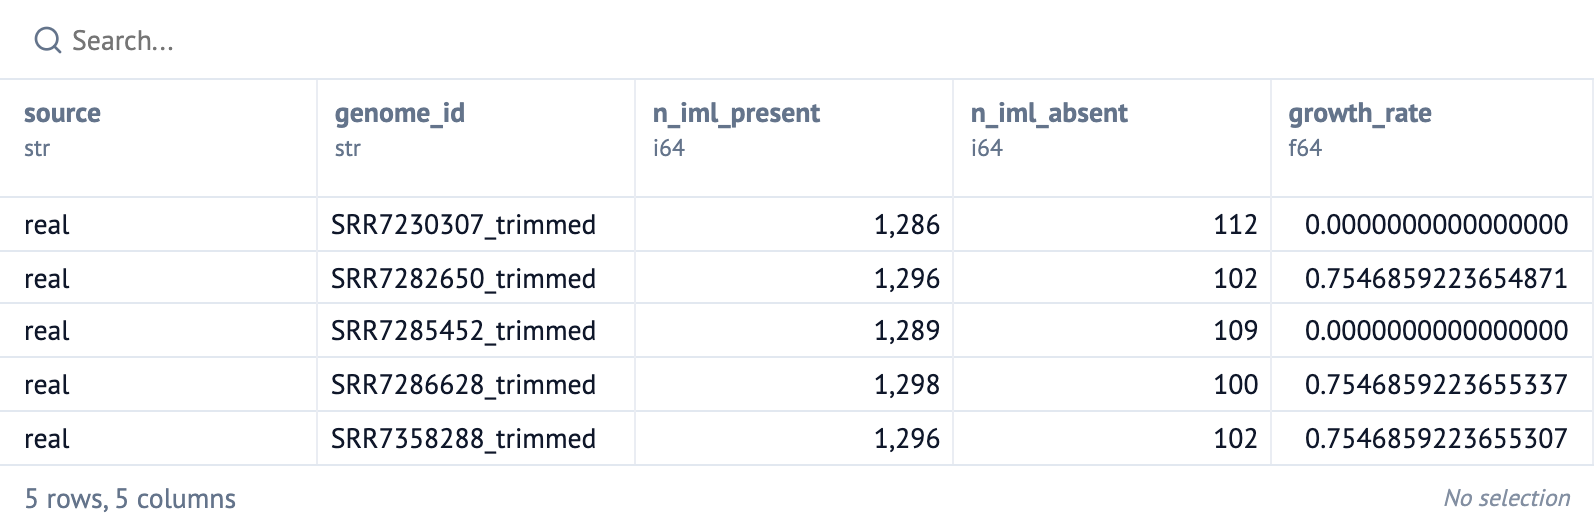

In [ ]:
fba_rows = []
for _src, _items in sample_sources.items():
    for _gid, _genes in _items:
        _genome_norm = {normalize_gene(g) for g in _genes}
        present_b = {
            bnum
            for bnum in iml_pangenome_known
            if iml_bnum_to_names[bnum] & _genome_norm
        }
        absent_in_iml = iml_pangenome_known - present_b
        with iml as m:
            for _gene_id in absent_in_iml:
                m.genes.get_by_id(_gene_id).knock_out()
            _sol = m.optimize()
            _growth = (
                _sol.objective_value
                if _sol.status == "optimal" and _sol.objective_value is not None
                else 0.0
            )
        _growth = float(_growth)
        if abs(_growth) < 1e-6:
            _growth = 0.0
        fba_rows.append(
            {
                "source": _src,
                "genome_id": _gid,
                "n_iml_present": len(present_b),
                "n_iml_absent": len(absent_in_iml),
                "growth_rate": _growth,
            }
        )

fba_df = pl.DataFrame(fba_rows)
print(f"fba_df: {fba_df.shape}")
fba_df.head()

## 8. Growth-rate distribution

Violin plot of predicted growth rate per genome — denser regions are
wider. Dashed line: WT iML1515 growth (≈ 0.877). Anything > 0 is
mechanistically viable on glucose minimal; anything close to WT is
metabolically intact. Use this view rather than a strip plot — the
growth distribution is multi-modal (zero, mid-cost, near-WT) and dot
overlap obscures the structure.

WT iML1515 growth: 0.8770 h⁻¹


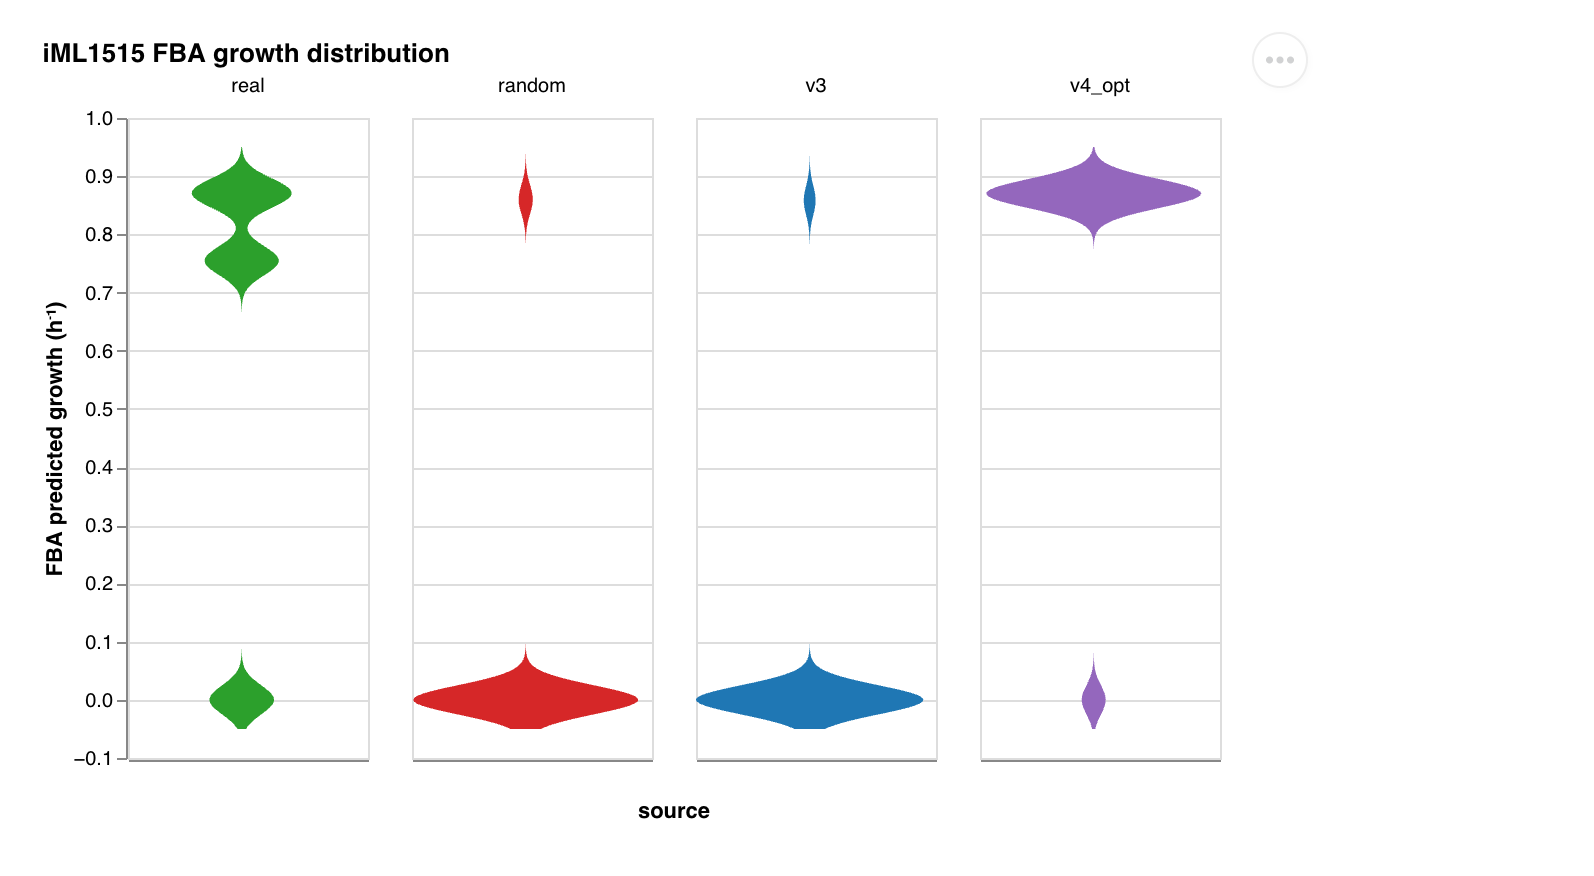

In [ ]:
_SRC_ORDER = ["real", "random", "v3", "v4_opt"]
_SRC_COLORS = {
    "real": "#2ca02c",
    "random": "#d62728",
    "v3": "#1f77b4",
    "v4_opt": "#9467bd",
}

violin_fba = (
    alt.Chart(fba_df.to_pandas())
    .transform_density(
        "growth_rate",
        as_=["growth_rate", "density"],
        groupby=["source"],
        extent=[-0.05, 0.95],
        steps=300,
        bandwidth=0.025,
        counts=True,
    )
    .mark_area(orient="horizontal")
    .encode(
        y=alt.Y("growth_rate:Q", title="FBA predicted growth (h⁻¹)"),
        x=alt.X(
            "density:Q",
            stack="center",
            impute=None,
            title=None,
            axis=alt.Axis(labels=False, ticks=False, grid=False),
        ),
        color=alt.Color(
            "source:N",
            scale=alt.Scale(
                domain=list(_SRC_COLORS.keys()),
                range=list(_SRC_COLORS.values()),
            ),
            legend=None,
        ),
        column=alt.Column(
            "source:N", sort=_SRC_ORDER, header=alt.Header(titleOrient="bottom")
        ),
    )
    .properties(width=120, height=320, title="iML1515 FBA growth distribution")
)
print(f"WT iML1515 growth: {wt_growth:.4f} h⁻¹")
violin_fba

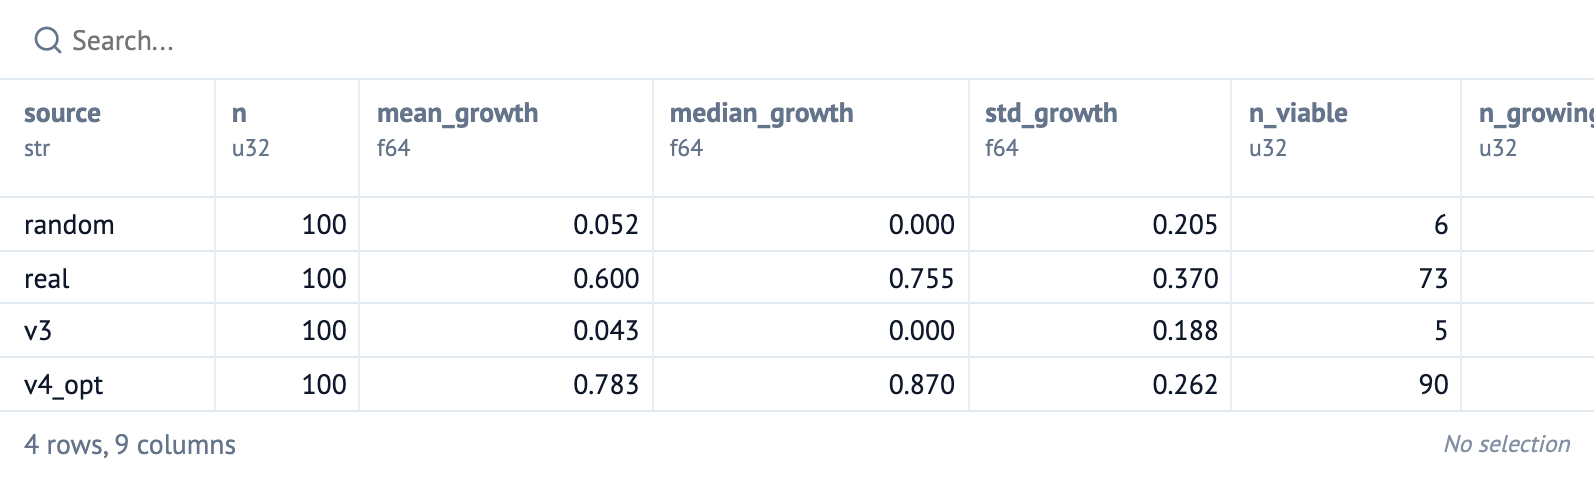

In [ ]:
fba_summary = (
    fba_df.group_by("source")
    .agg(
        [
            pl.len().alias("n"),
            pl.col("growth_rate").mean().round(3).alias("mean_growth"),
            pl.col("growth_rate").median().round(3).alias("median_growth"),
            pl.col("growth_rate").std().round(3).alias("std_growth"),
            (pl.col("growth_rate") > 0.01).sum().alias("n_viable"),
            (pl.col("growth_rate") > 0.1).sum().alias("n_growing"),
        ]
    )
    .with_columns(
        (pl.col("n_viable") / pl.col("n") * 100).round(1).alias("pct_viable"),
        (pl.col("n_growing") / pl.col("n") * 100).round(1).alias("pct_growing"),
    )
    .sort("source")
)
fba_summary

## 9. Tier-1 vs Tier-2 agreement

Compact joint view: module coverage at ≥80% versus FBA growth. Density in
the upper-right means the two tiers agree.

In [ ]:
_t80 = (
    long_df.group_by(["source", "genome_id"])
    .agg((pl.col("completeness") >= 0.8).sum().alias("n_modules_80pct"))
)
joined = fba_df.join(_t80, on=["source", "genome_id"])

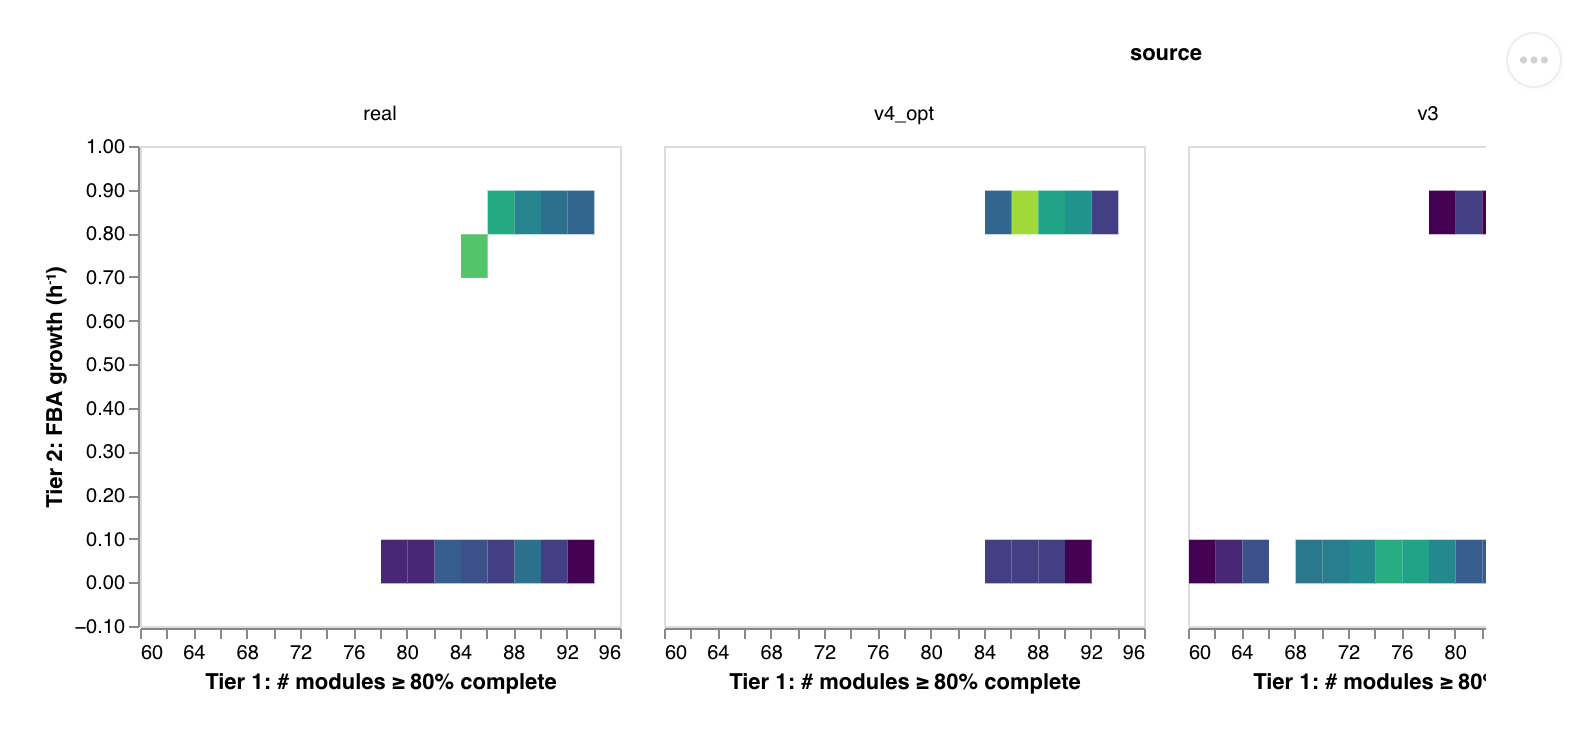

In [ ]:
_SRC_ORDER = ["real", "random", "v3", "v4_opt"]
(
    alt.Chart(joined.to_pandas())
    .mark_rect()
    .encode(
        x=alt.X(
            "n_modules_80pct:Q",
            bin=alt.Bin(maxbins=20, extent=[60, 95]),
            title="Tier 1: # modules ≥ 80% complete",
        ),
        y=alt.Y(
            "growth_rate:Q",
            bin=alt.Bin(maxbins=15, extent=[-0.05, 0.95]),
            title="Tier 2: FBA growth (h⁻¹)",
        ),
        color=alt.Color(
            "count():Q",
            scale=alt.Scale(scheme="viridis", type="symlog"),
            title="# genomes",
        ),
        tooltip=[
            alt.Tooltip("source:N"),
            alt.Tooltip("count():Q", title="n genomes"),
        ],
    )
    .properties(width=240, height=240)
    .facet(column=alt.Column("source:N", sort=_SRC_ORDER))
)

# 10. Operating point: the 0.5 decode threshold is the problem

Everything above thresholds the VAE decoder at 0.5 — an arbitrary cut that
discards the model's *continuous* gene ranking. It slices through the band of
genes v3 scores 0.4–0.5, which turn out to be essential metabolic genes, so
the 0.5 genome looks no better than random. Sweeping the threshold traces the
genome-size ↔ viability frontier; comparing against a **size-matched** random
baseline at each point is the fair test of whether the VAE's gene *selection*
beats a frequency-weighted baseline of the same gene *count*.

In [ ]:
import sys as _sys

_root = DATA_DIR.parent
for _p in (str(_root / "src"), str(_root / "evaluation")):
    if _p not in _sys.path:
        _sys.path.insert(0, _p)
# Reuse the canonical sample/repair code (same source of truth as the data
# files generated by generate_random_baseline.py / the binary_converter
# pipeline) rather than reimplementing it here.
from genome_minimizer_2.explore_data.binary_converter import (
    add_essential_genes,
    load_essential_set,
)
from generate_random_baseline import compute_gene_frequencies, sample_random_genomes

v3_continuous = np.load(EVAL_DATA / "v3" / "v3_samples.npy")
gene_order = np.asarray(pangenome_genes)
assert v3_continuous.shape[1] == gene_order.size, (
    "v3 sample columns must align with the pangenome gene order"
)

_essential_set = load_essential_set(str(DATA_DIR / "essential_genes.csv"))

# Per-gene frequencies (prevalence), cached to avoid re-reading the full
# matrix. The cache stores exactly what compute_gene_frequencies returns, so
# the cached and canonical paths sample identically.
_prev_path = DATA_DIR / "gene_prevalence.npy"
if _prev_path.exists():
    _gene_names, _gene_freq = gene_order, np.load(_prev_path)
else:
    _gene_names, _gene_freq = compute_gene_frequencies(
        DATA_DIR / "F4_complete_presence_absence.csv"
    )
    np.save(_prev_path, _gene_freq)

def make_random(target_size, n=50, seed=42):
    return sample_random_genomes(
        _gene_names, _gene_freq, int(target_size), n, np.random.default_rng(seed)
    )

def repair_essentials(gene_lists):
    return [add_essential_genes(g, _essential_set) for g in gene_lists]

In [ ]:
def fba_growth(gene_names):
    _norm = {normalize_gene(g) for g in gene_names}
    _present = {b for b in iml_pangenome_known if iml_bnum_to_names[b] & _norm}
    with iml as _m:
        for _absent in iml_pangenome_known - _present:
            _m.genes.get_by_id(_absent).knock_out()
        _sol = _m.optimize()
        _val = _sol.objective_value if _sol.status == "optimal" and _sol.objective_value else 0.0
    return 0.0 if abs(_val) < 1e-6 else float(_val)

def n_modules_complete(gene_names, frac):
    _bn = {pangenome_to_bnum[g] for g in gene_names if g in pangenome_to_bnum}
    return sum(len(_bn & mg) / len(mg) >= frac for mg in module_genes.values() if mg)

/Users/mcclainthiel/Projects/PhD/genome-minimizer-2/.venv/lib/python3.11/site-packages/cobra/util/solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)


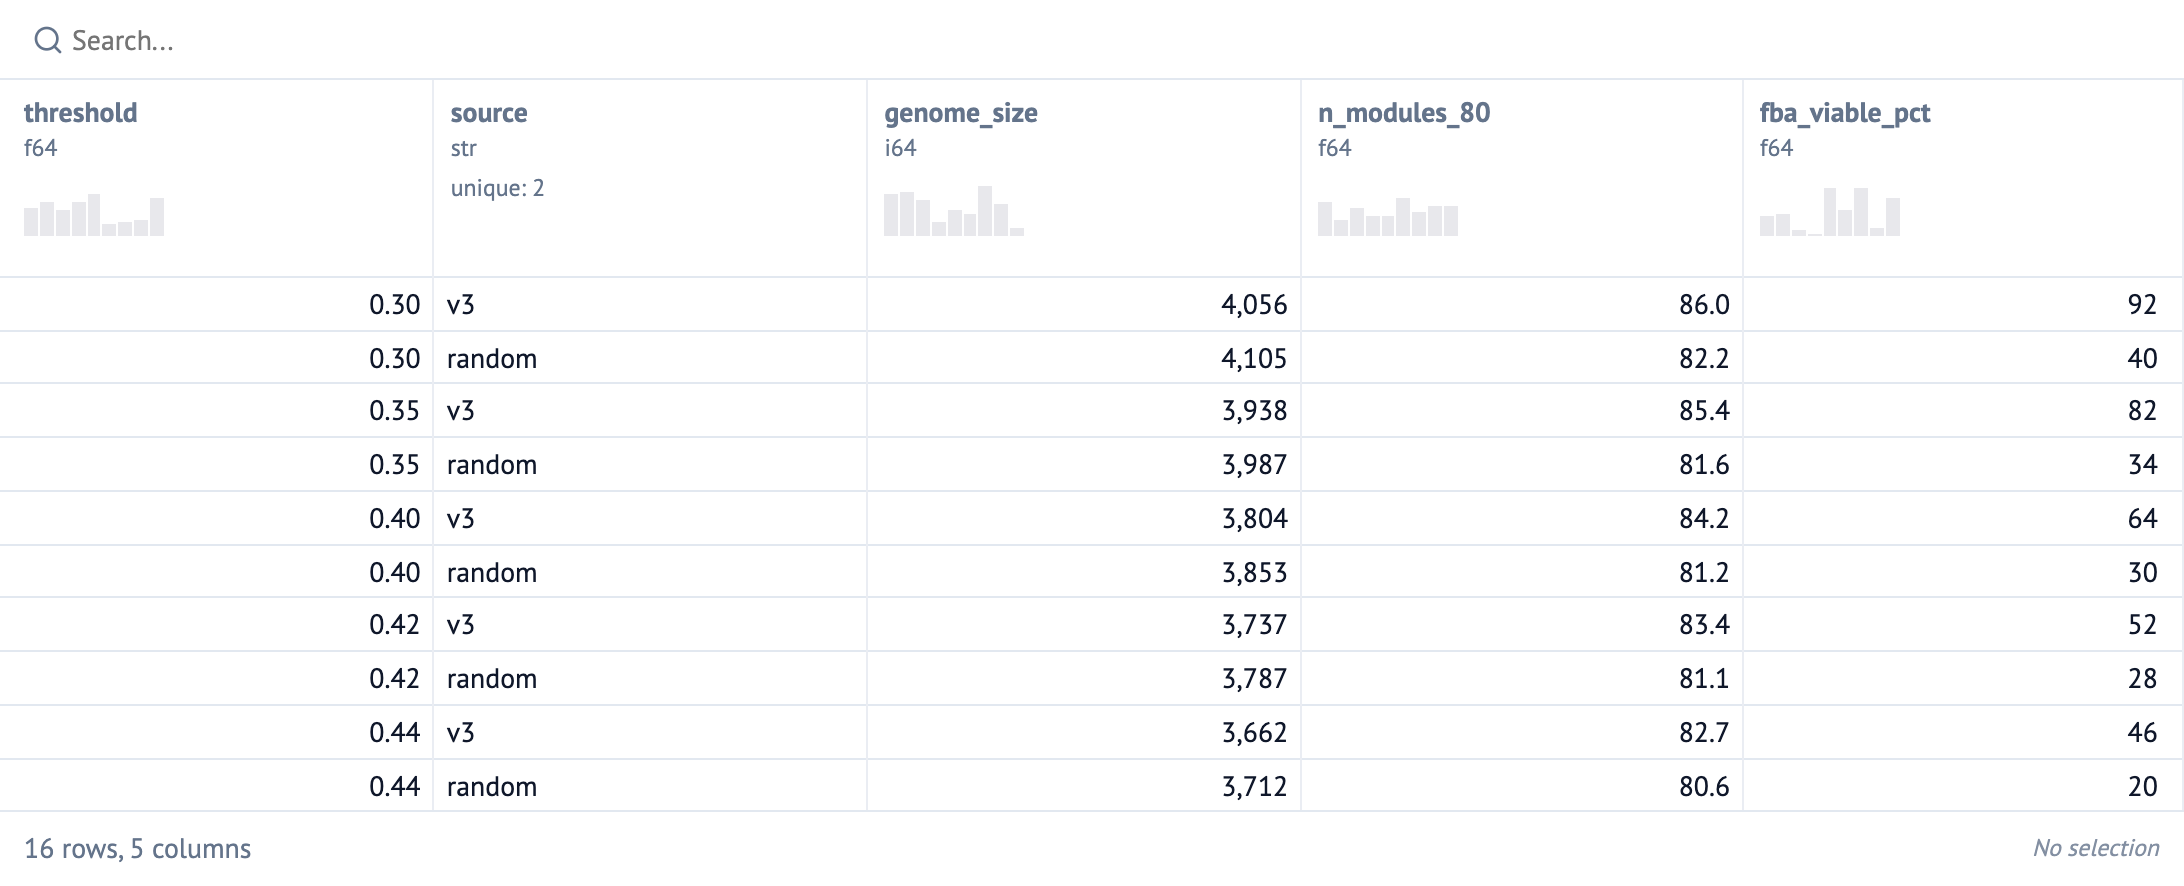

In [ ]:
_grid = [0.30, 0.35, 0.40, 0.42, 0.44, 0.46, 0.48, 0.50]
_rows = []
for _t in _grid:
    _v3 = repair_essentials(
        [gene_order[v3_continuous[i] > _t].tolist() for i in range(v3_continuous.shape[0])]
    )
    _size = int(round(np.mean([len(x) for x in _v3])))
    _rnd = repair_essentials(make_random(_size, n=50, seed=42))
    for _src, _gl in (("v3", _v3), ("random", _rnd)):
        _growth = np.array([fba_growth(x) for x in _gl])
        _rows.append(
            {
                "threshold": _t,
                "source": _src,
                "genome_size": int(round(np.mean([len(x) for x in _gl]))),
                "n_modules_80": round(float(np.mean([n_modules_complete(x, 0.8) for x in _gl])), 1),
                "fba_viable_pct": round(float(100 * np.mean(_growth > 0.01)), 0),
            }
        )
sweep_df = pl.DataFrame(_rows)
sweep_df

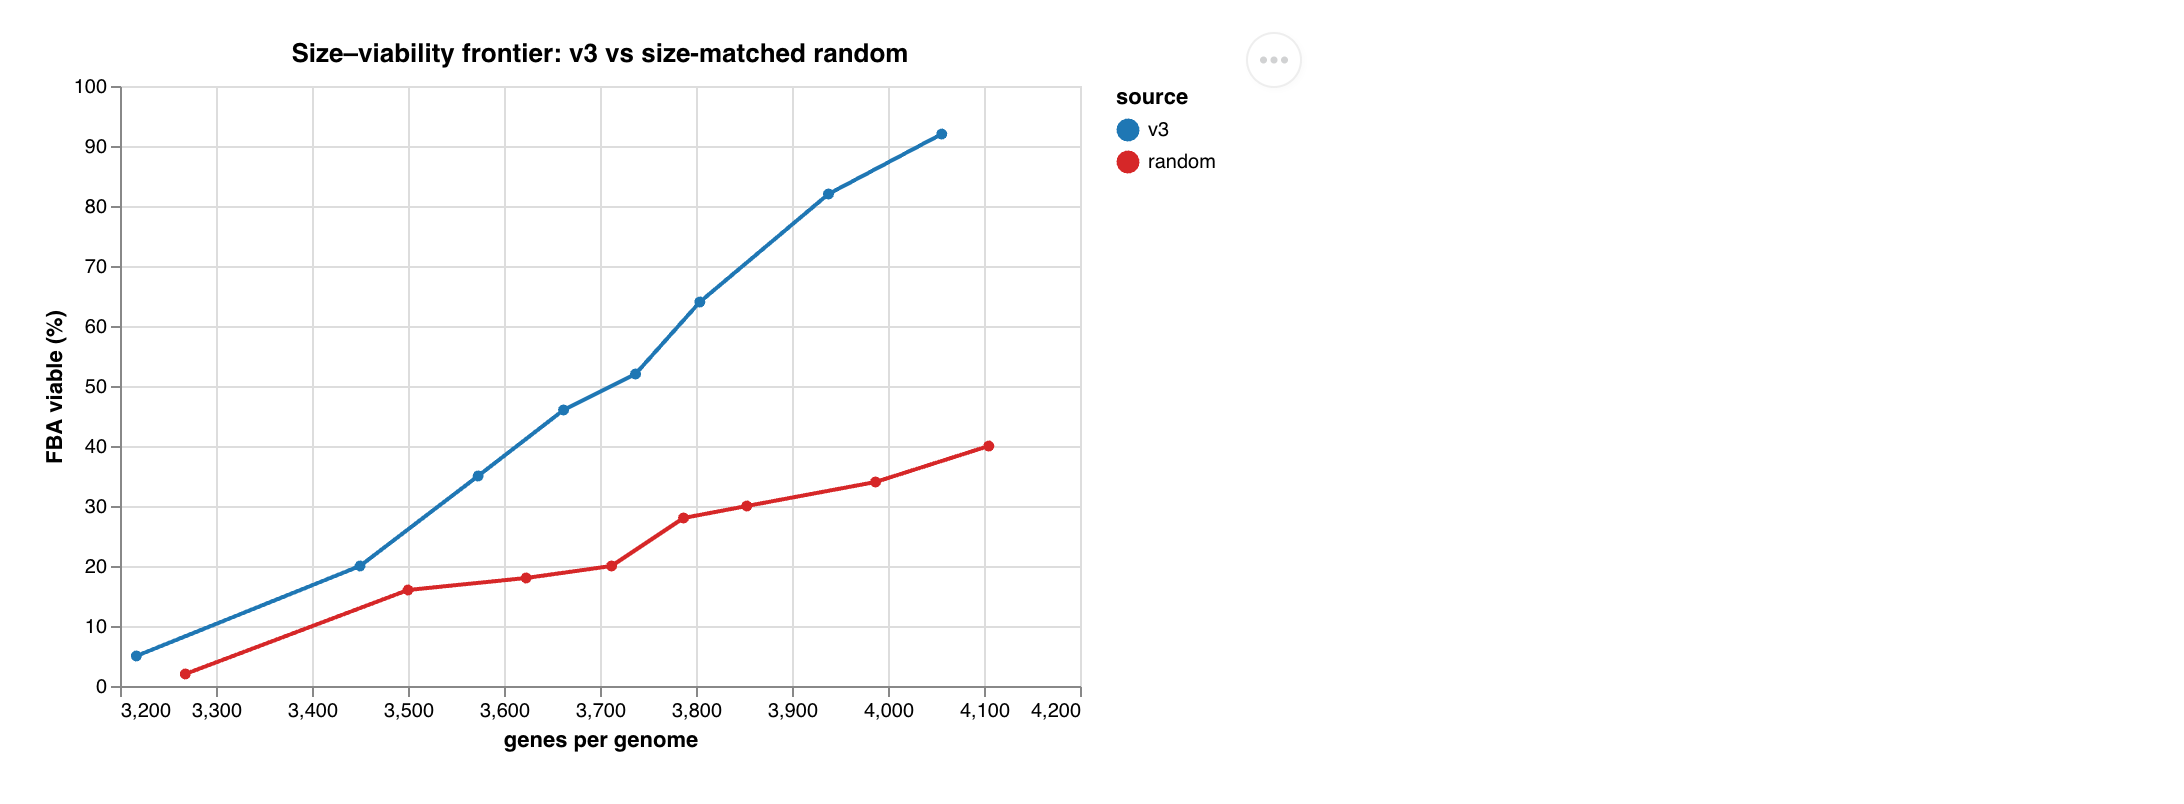

In [ ]:
alt.Chart(sweep_df.to_pandas()).mark_line(point=True).encode(
    x=alt.X("genome_size:Q", title="genes per genome", scale=alt.Scale(zero=False)),
    y=alt.Y("fba_viable_pct:Q", title="FBA viable (%)"),
    color=alt.Color(
        "source:N",
        scale=alt.Scale(domain=["v3", "random"], range=["#1f77b4", "#d62728"]),
    ),
    tooltip=["threshold", "source", "genome_size", "fba_viable_pct", "n_modules_80"],
).properties(
    width=480, height=300, title="Size–viability frontier: v3 vs size-matched random"
)

In [ ]:
_v3 = sweep_df.filter(pl.col("source") == "v3")
_viable = _v3.filter(pl.col("fba_viable_pct") >= 60).sort("genome_size")
best_threshold = (
    float(_viable["threshold"][0])
    if _viable.height
    else float(_v3.sort("fba_viable_pct", descending=True)["threshold"][0])
)
best_size = int(_v3.filter(pl.col("threshold") == best_threshold)["genome_size"][0])
mo.md(
    f"""
    ### Chosen operating point: threshold **{best_threshold:.2f}** → ~{best_size} genes

    Rule: the most aggressive cut (smallest genome) that still keeps a clear
    majority (≥60%) of samples FBA-viable — ~{100 * (1 - best_size / 4739):.0f}% smaller
    than a real strain, viable, and ahead of size-matched random on both tiers.
    """
)

<span class="markdown prose dark:prose-invert contents"><h3 id="chosen-operating-point-threshold-040-3804-genes">Chosen operating point: threshold <strong>0.40</strong> → ~3804 genes</h3>
<span class="paragraph">Rule: the most aggressive cut (smallest genome) that still keeps a clear
majority (≥60%) of samples FBA-viable — ~20% smaller
than a real strain, viable, and ahead of size-matched random on both tiers.</span></span>

# 11. Two-tier eval at the chosen operating point

Re-run both tiers with v3 decoded at the chosen threshold and the random
baseline regenerated to the **same** genome size, so the comparison isolates
gene *selection* rather than gene *count*. `real` is the wild-type reference.

/Users/mcclainthiel/Projects/PhD/genome-minimizer-2/.venv/lib/python3.11/site-packages/cobra/util/solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)


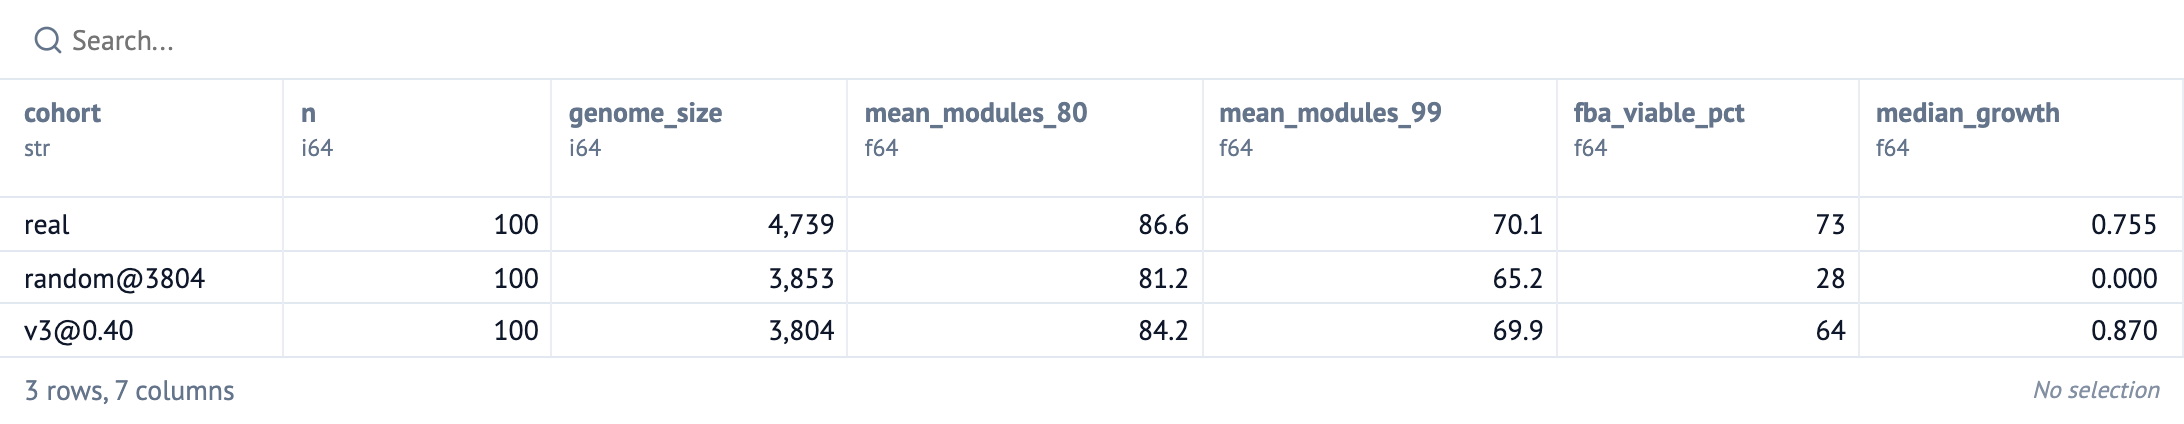

In [ ]:
_real = [genes for _, genes in sample_sources["real"]]
_v3 = repair_essentials(
    [gene_order[v3_continuous[i] > best_threshold].tolist() for i in range(v3_continuous.shape[0])]
)
_rnd = repair_essentials(make_random(best_size, n=100, seed=42))
_cohorts = [("real", _real), (f"random@{best_size}", _rnd), (f"v3@{best_threshold:.2f}", _v3)]

_rows = []
for _name, _gl in _cohorts:
    _growth = np.array([fba_growth(x) for x in _gl])
    _rows.append(
        {
            "cohort": _name,
            "n": len(_gl),
            "genome_size": int(round(np.mean([len(x) for x in _gl]))),
            "mean_modules_80": round(float(np.mean([n_modules_complete(x, 0.8) for x in _gl])), 1),
            "mean_modules_99": round(float(np.mean([n_modules_complete(x, 0.99) for x in _gl])), 1),
            "fba_viable_pct": round(float(100 * np.mean(_growth > 0.01)), 1),
            "median_growth": round(float(np.median(_growth)), 3),
        }
    )
reanalysis_df = pl.DataFrame(_rows)
reanalysis_df

In [ ]:
_pdf = reanalysis_df.to_pandas().melt(
    id_vars="cohort",
    value_vars=["fba_viable_pct", "mean_modules_80"],
    var_name="metric",
    value_name="value",
)
alt.Chart(_pdf).mark_bar().encode(
    x=alt.X("cohort:N", title=None, sort=None),
    y=alt.Y("value:Q", title=None),
    color=alt.Color("cohort:N", legend=None),
    column=alt.Column("metric:N", title=None),
    tooltip=["cohort", "metric", "value"],
).resolve_scale(y="independent").properties(width=170, height=240)